# Analisis de sentimiento y Naive Bayes usando posicionamientos de marcas

In [ ]:
#Se importan las librerías
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Se carga el archivo
df = pd.read_csv("/content/drive/MyDrive/brand_positioning_10000.csv")

print(df.head())
print(df.tail())

X = df['review'].astype(str)
y = df['sentiment']

   id   marca            aspecto  \
0   1  MarcaA         notoriedad   
1   2  MarcaB  calidad_percibida   
2   3  MarcaA       valor_precio   
3   4  MarcaA  calidad_percibida   
4   5  MarcaE         notoriedad   

                                           review  sentiment  
0  La reconozco al instante por su logo y campaña          1  
1              No cumple el estándar que esperaba          0  
2                     Cuesta más de lo que ofrece          0  
3              No cumple el estándar que esperaba          0  
4                       Poca visibilidad en redes          0  
         id   marca            aspecto  \
9995   9996  MarcaD         notoriedad   
9996   9997  MarcaA       valor_precio   
9997   9998  MarcaB  calidad_percibida   
9998   9999  MarcaD       valor_precio   
9999  10000  MarcaC            lealtad   

                                      review  sentiment  
9995    No recuerdo ninguna campaña reciente          0  
9996             Cuesta más de lo qu

In [ ]:
# se genera la relación entre Train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Se genera el pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=8000, stop_words=None)),
    ("nb", MultinomialNB(alpha=1.0))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Métricas globales
accuracy = metrics.accuracy_score(y_test, y_pred)
conf_matrix = metrics.confusion_matrix(y_test, y_pred)

# Métricas por aspecto
test_df = df.loc[y_test.index].copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = y_pred

per_aspect_metrics = []
for aspecto, group in test_df.groupby('aspecto'):
    if len(group) < 5:
        continue
    m = {
        'aspecto': aspecto,
        'n_test': len(group),
        'accuracy': metrics.accuracy_score(group['y_true'], group['y_pred']),
        'precision_macro': metrics.precision_score(group['y_true'], group['y_pred'], average='macro', zero_division=0),
        'recall_macro': metrics.recall_score(group['y_true'], group['y_pred'], average='macro', zero_division=0),
        'f1_macro': metrics.f1_score(group['y_true'], group['y_pred'], average='macro', zero_division=0)
    }
    per_aspect_metrics.append(m)

per_aspect_df = pd.DataFrame(per_aspect_metrics)



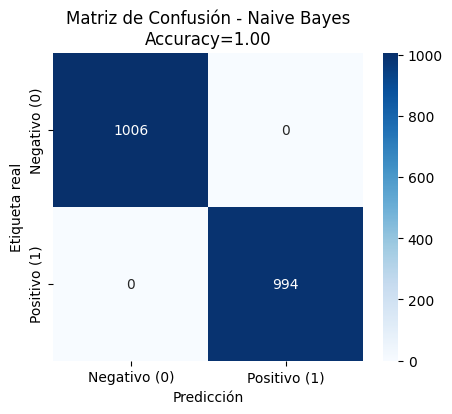

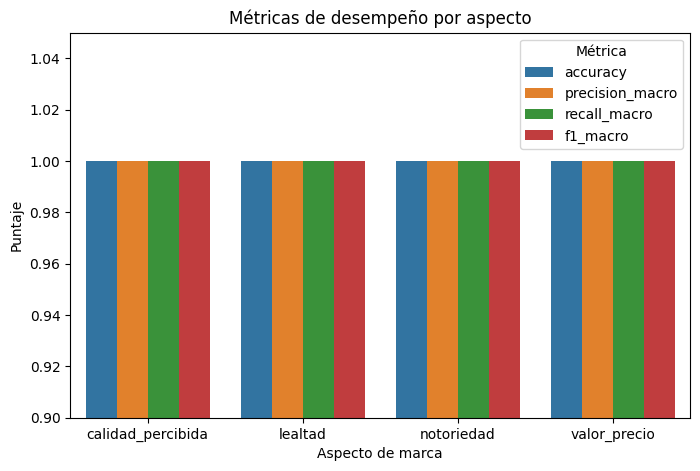

/tmp/ipython-input-3026912764.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_tokens_df[0].head(10), x=list(range(10, 0, -1)), ax=axes[0], palette="Reds_r")
/tmp/ipython-input-3026912764.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_tokens_df[1].head(10), x=list(range(10, 0, -1)), ax=axes[1], palette="Greens_r")


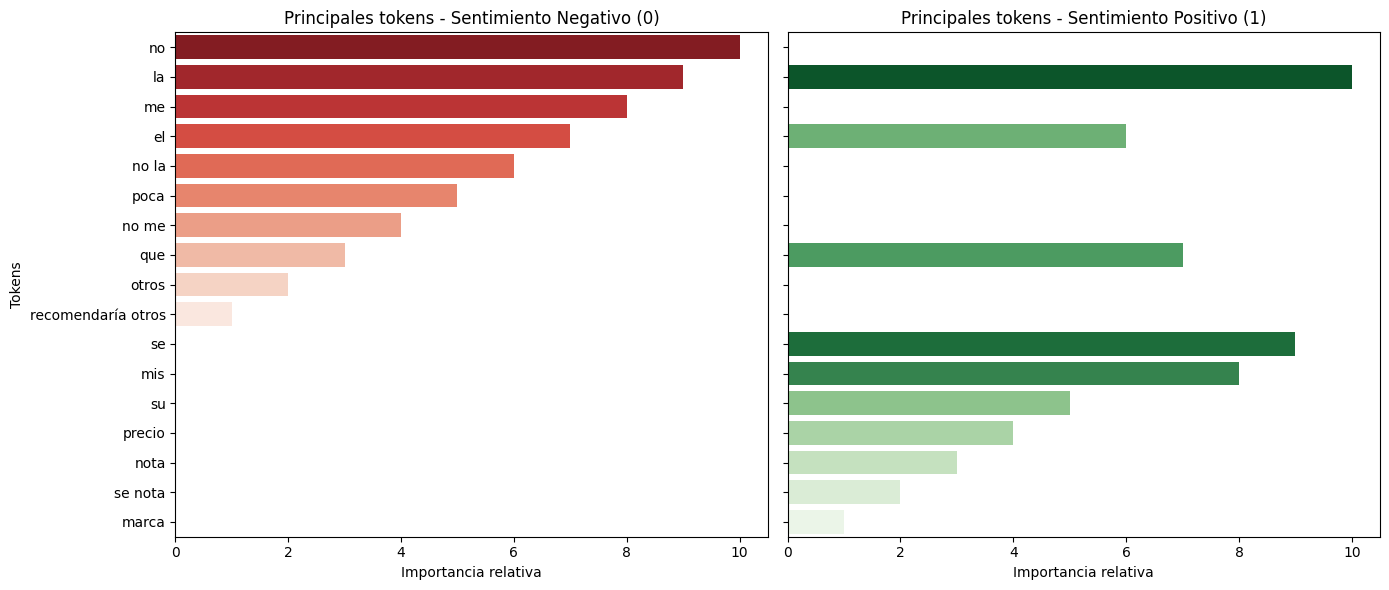

In [ ]:
# --- 1. Gráfico de matriz de confusión ---
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativo (0)", "Positivo (1)"],
            yticklabels=["Negativo (0)", "Positivo (1)"],
            ax=ax)
plt.title(f"Matriz de Confusión - Naive Bayes\nAccuracy={accuracy:.2f}")
plt.ylabel("Etiqueta real")
plt.xlabel("Predicción")
plt.show()

# --- 2. Gráfico de métricas por aspecto ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=per_aspect_df.melt(id_vars=["aspecto", "n_test"], value_vars=["accuracy", "precision_macro", "recall_macro", "f1_macro"]),
            x="aspecto", y="value", hue="variable", ax=ax)
plt.ylim(0.9, 1.05)
plt.title("Métricas de desempeño por aspecto")
plt.ylabel("Puntaje")
plt.xlabel("Aspecto de marca")
plt.legend(title="Métrica")
plt.show()

# --- 3. Top tokens por clase ---
tfidf = pipeline.named_steps['tfidf']
nb = pipeline.named_steps['nb']

feature_names = tfidf.get_feature_names_out()
class_labels = nb.classes_
topn = 15
top_tokens = {}
for i, cls in enumerate(class_labels):
    topn_ids = np.argsort(nb.feature_log_prob_[i])[-topn:][::-1]
    top_tokens[int(cls)] = [feature_names[j] for j in topn_ids]

top_tokens_df = pd.DataFrame.from_dict(top_tokens, orient='index').transpose().fillna('')

# Visualización de top tokens
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(y=top_tokens_df[0].head(10), x=list(range(10, 0, -1)), ax=axes[0], palette="Reds_r")
axes[0].set_title("Principales tokens - Sentimiento Negativo (0)")
axes[0].set_xlabel("Importancia relativa")
axes[0].set_ylabel("Tokens")

sns.barplot(y=top_tokens_df[1].head(10), x=list(range(10, 0, -1)), ax=axes[1], palette="Greens_r")
axes[1].set_title("Principales tokens - Sentimiento Positivo (1)")
axes[1].set_xlabel("Importancia relativa")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()